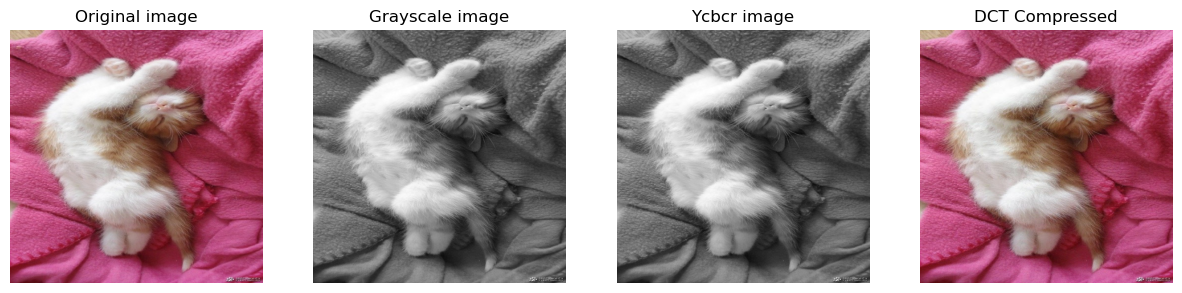

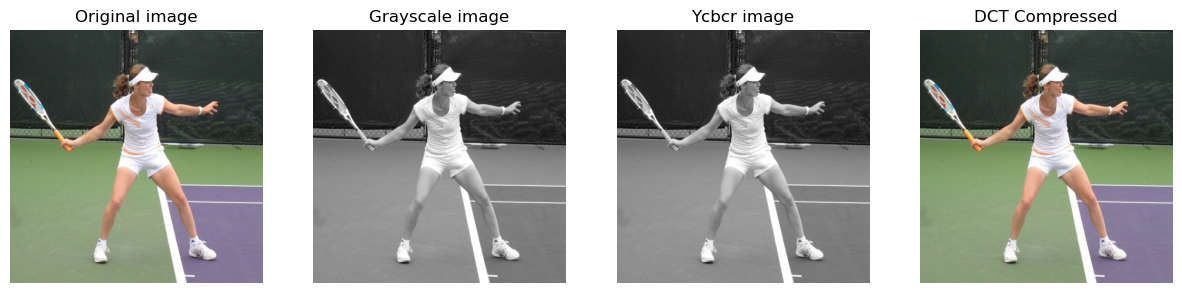

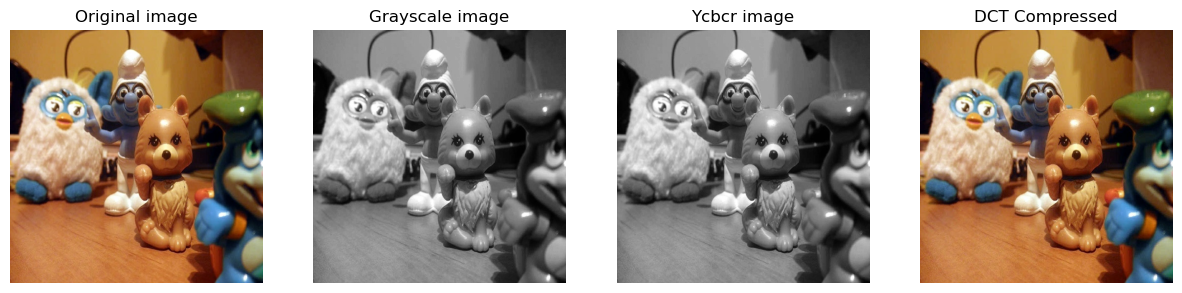

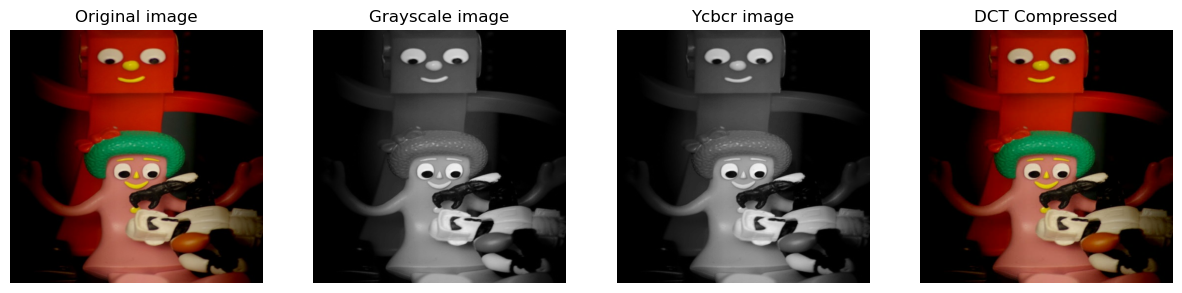

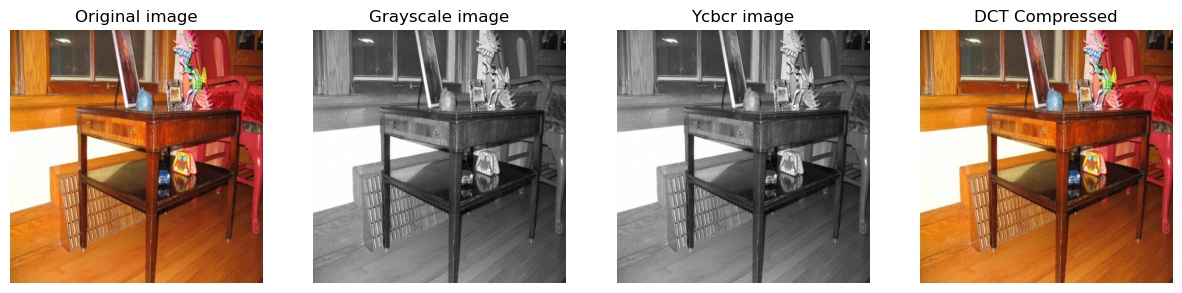

In [ ]:
import cv2
import numpy as np
from scipy.fftpack import dct, idct
import os
import matplotlib.pyplot as plt

INPUT_DIR = r"C:\Users\jaich\Downloads\archive (1)\Ground_truth"
OUTPUT_DIR = os.path.join(INPUT_DIR, "DCT_compressed")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

def compress_image(img, quality=30, block_size=8):
    """Compress image using DCT on YCbCr channels"""
    ycbcr = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb).astype(np.float32)
    h, w, _ = ycbcr.shape
    
    # Quantization matrix (simple)
    Q = np.ones((block_size, block_size)) * (100-quality)/10 + 1
    Q[0,0] = 1
    
    # Pad image to be divisible by block_size
    padded_h = int(np.ceil(h / block_size) * block_size)
    padded_w = int(np.ceil(w / block_size) * block_size)
    padded = np.zeros((padded_h, padded_w, 3), dtype=np.float32)
    padded[:h,:w,:] = ycbcr
    compressed = np.zeros_like(padded)
    
    # DCT compression per channel
    for ch in range(3):
        for i in range(0, padded_h, block_size):
            for j in range(0, padded_w, block_size):
                block = padded[i:i+block_size, j:j+block_size, ch] - 128
                block = np.round(dct2(block)/Q) * Q
                compressed[i:i+block_size, j:j+block_size, ch] = idct2(block) + 128
                
    compressed = np.clip(compressed[:h,:w,:], 0, 255).astype(np.uint8)
    return cv2.cvtColor(compressed, cv2.COLOR_YCrCb2BGR), ycbcr.astype(np.uint8)

display_count = 0
for file in os.listdir(INPUT_DIR):
    if not file.lower().endswith((".jpg", ".png")):
        continue
    
    path = os.path.join(INPUT_DIR, file)
    img = cv2.imread(path)
    if img is None:
        continue
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    compressed_img, ycbcr_img = compress_image(img, quality=30)
    
    # Save compressed image
    base, ext = os.path.splitext(file)
    cv2.imwrite(os.path.join(OUTPUT_DIR, f"{base}_dct.jpg"), compressed_img)
    
    # Display first 10 images
    if display_count < 5:
        plt.figure(figsize=(15,4))
        
        plt.subplot(1,4,1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original image"); plt.axis('off')
        
        plt.subplot(1,4,2)
        plt.imshow(gray, cmap='gray')
        plt.title("Grayscale image"); plt.axis('off')
        
        plt.subplot(1,4,3)
        plt.imshow(ycbcr_img[:,:,0], cmap='gray')
        plt.title("Ycbcr image"); plt.axis('off')
        
        plt.subplot(1,4,4)
        plt.imshow(cv2.cvtColor(compressed_img, cv2.COLOR_BGR2RGB))
        plt.title("DCT Compressed"); plt.axis('off')
        
        plt.show()
        display_count += 1